In [5]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

# Number of records
n = 1000

# -----------------------------
# Basic logistics information
# -----------------------------

delivery_ids = [f"D{100001 + i}" for i in range(n)]

dates = pd.date_range(
    start="2026-01-01",
    end="2026-03-31",
    periods=n
)

vehicle_types = np.random.choice(
    ["Bike", "Van", "Truck"],
    size=n,
    p=[0.38, 0.42, 0.20]
)

origins = np.random.choice(
    ["Warehouse A", "Warehouse B", "Warehouse C"],
    size=n,
    p=[0.40, 0.35, 0.25]
)

destination_zones = np.random.choice(
    ["Urban", "Suburban", "Semi-urban", "Rural"],
    size=n,
    p=[0.35, 0.30, 0.22, 0.13]
)

traffic_levels = np.random.choice(
    ["Low", "Medium", "High"],
    size=n,
    p=[0.30, 0.45, 0.25]
)

weather_conditions = np.random.choice(
    ["Normal", "Rain", "Storm"],
    size=n,
    p=[0.72, 0.21, 0.07]
)

# -----------------------------
# Distance
# -----------------------------

distance = np.random.normal(20, 8, n)
distance = np.clip(distance, 3, 60)

# Rural deliveries generally have longer distances
distance += np.where(destination_zones == "Rural", 12, 0)
distance = np.round(distance, 2)

# -----------------------------
# Package and vehicle capacity
# -----------------------------

package_count = np.random.randint(1, 16, n)

vehicle_capacity = np.select(
    [
        vehicle_types == "Bike",
        vehicle_types == "Van",
        vehicle_types == "Truck"
    ],
    [
        50,
        200,
        500
    ]
)

load_weight = np.random.uniform(5, 180, n)

# Keep loads somewhat realistic relative to vehicle type
load_weight = np.where(
    vehicle_types == "Bike",
    np.random.uniform(5, 45, n),
    load_weight
)

load_weight = np.where(
    vehicle_types == "Truck",
    np.random.uniform(80, 450, n),
    load_weight
)

load_weight = np.round(load_weight, 2)

# -----------------------------
# Delivery time
# -----------------------------

delivery_time = (
    45
    + distance * 2.0
    + package_count * 1.5
    + np.where(traffic_levels == "Medium", 10, 0)
    + np.where(traffic_levels == "High", 25, 0)
    + np.where(weather_conditions == "Rain", 10, 0)
    + np.where(weather_conditions == "Storm", 25, 0)
    + np.random.normal(0, 10, n)
)

delivery_time = np.clip(delivery_time, 20, 300)
delivery_time = np.round(delivery_time, 2)

# -----------------------------
# Delivery cost
# -----------------------------

delivery_cost = (
    70
    + distance * 4.2
    + package_count * 5
    + np.where(vehicle_types == "Van", 50, 0)
    + np.where(vehicle_types == "Truck", 150, 0)
    + np.random.normal(0, 25, n)
)

delivery_cost = np.clip(delivery_cost, 50, 800)
delivery_cost = np.round(delivery_cost, 2)

# -----------------------------
# Fuel cost
# -----------------------------

fuel_cost = (
    distance * np.where(
        vehicle_types == "Bike",
        1.5,
        np.where(
            vehicle_types == "Van",
            4.0,
            7.0
        )
    )
)

fuel_cost += np.random.normal(0, 8, n)
fuel_cost = np.clip(fuel_cost, 10, 500)
fuel_cost = np.round(fuel_cost, 2)

# -----------------------------
# Customer rating
# -----------------------------

customer_rating = (
    4.7
    - np.where(traffic_levels == "High", 0.35, 0)
    - np.where(weather_conditions == "Storm", 0.30, 0)
    - np.where(delivery_time > 150, 0.20, 0)
    + np.random.normal(0, 0.15, n)
)

customer_rating = np.clip(customer_rating, 1, 5)
customer_rating = np.round(customer_rating, 2)

# -----------------------------
# On-time delivery
# -----------------------------

on_time_probability = (
    0.90
    - np.where(traffic_levels == "Medium", 0.08, 0)
    - np.where(traffic_levels == "High", 0.18, 0)
    - np.where(weather_conditions == "Rain", 0.05, 0)
    - np.where(weather_conditions == "Storm", 0.15, 0)
)

on_time = np.random.random(n) < on_time_probability

on_time_delivery = np.where(
    on_time,
    "Yes",
    "No"
)

# -----------------------------
# Create DataFrame
# -----------------------------

raw_logistics_df = pd.DataFrame({
    "Delivery_ID": delivery_ids,
    "Delivery_Date": dates,
    "Vehicle_Type": vehicle_types,
    "Origin": origins,
    "Destination_Zone": destination_zones,
    "Distance_KM": distance,
    "Traffic_Level": traffic_levels,
    "Weather_Condition": weather_conditions,
    "Package_Count": package_count,
    "Vehicle_Capacity_KG": vehicle_capacity,
    "Load_Weight_KG": load_weight,
    "Delivery_Time_Minutes": delivery_time,
    "Delivery_Cost_INR": delivery_cost,
    "Fuel_Cost_INR": fuel_cost,
    "Customer_Rating": customer_rating,
    "On_Time_Delivery": on_time_delivery
})

# Display basic information
print("Dataset created successfully.")
print("Number of records:", len(raw_logistics_df))
print("Number of columns:", len(raw_logistics_df.columns))

display(raw_logistics_df.head(10))

Dataset created successfully.
Number of records: 1000
Number of columns: 16


,Delivery_ID,Delivery_Date,Vehicle_Type,Origin,Destination_Zone,Distance_KM,Traffic_Level,Weather_Condition,Package_Count,Vehicle_Capacity_KG,Load_Weight_KG,Delivery_Time_Minutes,Delivery_Cost_INR,Fuel_Cost_INR,Customer_Rating,On_Time_Delivery
0,D100001,2026-01-01 00:00:00.000000000,Bike,Warehouse A,Urban,15.22,Medium,Normal,2,50,31.82,69.45,150.98,30.63,4.84,Yes
1,D100002,2026-01-01 02:08:17.297297297,Truck,Warehouse B,Urban,3.00,High,Rain,13,500,284.30,102.22,260.23,17.62,4.15,No
2,D100003,2026-01-01 04:16:34.594594594,Van,Warehouse C,Rural,28.70,Low,Rain,1,200,142.97,96.27,253.20,116.35,4.85,Yes
3,D100004,2026-01-01 06:24:51.891891891,Van,Warehouse B,Urban,27.31,Medium,Normal,10,200,148.17,118.23,282.36,104.78,4.96,No
4,D100005,2026-01-01 08:33:09.189189189,Bike,Warehouse C,Urban,24.30,Medium,Normal,2,50,14.90,112.39,180.48,35.31,4.95,Yes
5,D100006,2026-01-01 10:41:26.486486486,Bike,Warehouse B,Semi-urban,23.43,High,Normal,12,50,25.26,119.81,241.39,36.84,4.17,Yes
6,D100007,2026-01-01 12:49:43.783783783,Bike,Warehouse B,Suburban,17.76,High,Normal,7,50,38.78,114.12,220.68,31.39,4.32,Yes
7,D100008,2026-01-01 14:58:01.081081081,Truck,Warehouse C,Semi-urban,9.77,Low,Normal,8,500,326.65,77.19,309.11,68.88,4.84,Yes
8,D100009,2026-01-01 17:06:18.378378378,Van,Warehouse A,Urban,24.12,Medium,Normal,5,200,22.46,108.35,241.31,76.59,4.53,No
9,D100010,2026-01-01 19:14:35.675675675,Van,Warehouse B,Suburban,13.33,Low,Normal,6,200,14.54,75.85,176.42,52.70,4.44,Yes


In [6]:
raw_logistics_df

,Delivery_ID,Delivery_Date,Vehicle_Type,Origin,Destination_Zone,Distance_KM,Traffic_Level,Weather_Condition,Package_Count,Vehicle_Capacity_KG,Load_Weight_KG,Delivery_Time_Minutes,Delivery_Cost_INR,Fuel_Cost_INR,Customer_Rating,On_Time_Delivery
0,D100001,2026-01-01 00:00:00.000000000,Bike,Warehouse A,Urban,15.22,Medium,Normal,2,50,31.82,69.45,150.98,30.63,4.84,Yes
1,D100002,2026-01-01 02:08:17.297297297,Truck,Warehouse B,Urban,3.00,High,Rain,13,500,284.30,102.22,260.23,17.62,4.15,No
2,D100003,2026-01-01 04:16:34.594594594,Van,Warehouse C,Rural,28.70,Low,Rain,1,200,142.97,96.27,253.20,116.35,4.85,Yes
3,D100004,2026-01-01 06:24:51.891891891,Van,Warehouse B,Urban,27.31,Medium,Normal,10,200,148.17,118.23,282.36,104.78,4.96,No
4,D100005,2026-01-01 08:33:09.189189189,Bike,Warehouse C,Urban,24.30,Medium,Normal,2,50,14.90,112.39,180.48,35.31,4.95,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,D100996,2026-03-30 15:26:50.810810810,Bike,Warehouse B,Semi-urban,29.84,Medium,Rain,13,50,24.34,134.93,263.87,38.16,4.75,Yes
996,D100997,2026-03-30 17:35:08.108108108,Truck,Warehouse C,Urban,27.86,Medium,Normal,14,500,130.26,119.85,429.69,193.85,4.54,Yes
997,D100998,2026-03-30 19:43:25.405405405,Bike,Warehouse A,Urban,8.80,Medium,Normal,11,50,35.57,95.54,174.88,18.15,4.60,Yes
998,D100999,2026-03-30 21:51:42.702702702,Truck,Warehouse A,Urban,24.70,Medium,Rain,12,500,367.18,130.02,425.46,179.07,4.60,Yes


In [8]:
# Create a copy so the original baseline dataset remains unchanged
logistics_raw_issues_df = raw_logistics_df.copy()

# Reproducible random generator
rng = np.random.default_rng(42)

# ---------------------------------------------------------
# 1. INTRODUCE MISSING VALUES
# ---------------------------------------------------------

missing_columns = [
    "Distance_KM",
    "Delivery_Time_Minutes",
    "Delivery_Cost_INR",
    "Weather_Condition",
    "Customer_Rating"
]

for column in missing_columns:
    indices = rng.choice(
        logistics_raw_issues_df.index,
        size=10,
        replace=False
    )
    logistics_raw_issues_df.loc[indices, column] = np.nan


# ---------------------------------------------------------
# 2. INTRODUCE DUPLICATE RECORDS
# ---------------------------------------------------------

duplicate_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=5,
    replace=False
)

duplicate_rows = logistics_raw_issues_df.loc[
    duplicate_indices
].copy()

logistics_raw_issues_df = pd.concat(
    [logistics_raw_issues_df, duplicate_rows],
    ignore_index=True
)


# ---------------------------------------------------------
# 3. INTRODUCE INCONSISTENT CATEGORICAL VALUES
# ---------------------------------------------------------

# Traffic-level inconsistencies
traffic_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=12,
    replace=False
)

traffic_replacements = {
    "Low": "low",
    "Medium": "medium",
    "High": "HIGH"
}

for idx in traffic_indices:
    current_value = logistics_raw_issues_df.loc[
        idx, "Traffic_Level"
    ]

    if pd.notna(current_value):
        logistics_raw_issues_df.loc[
            idx, "Traffic_Level"
        ] = traffic_replacements.get(
            current_value,
            current_value
        )


# Weather inconsistencies
weather_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=12,
    replace=False
)

weather_replacements = {
    "Normal": "normal",
    "Rain": "RAIN",
    "Storm": "storm"
}

for idx in weather_indices:
    current_value = logistics_raw_issues_df.loc[
        idx, "Weather_Condition"
    ]

    if pd.notna(current_value):
        logistics_raw_issues_df.loc[
            idx, "Weather_Condition"
        ] = weather_replacements.get(
            current_value,
            current_value
        )


# ---------------------------------------------------------
# 4. INTRODUCE NUMERICAL OUTLIERS
# ---------------------------------------------------------

outlier_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=5,
    replace=False
)

logistics_raw_issues_df.loc[
    outlier_indices,
    "Distance_KM"
] = logistics_raw_issues_df.loc[
    outlier_indices,
    "Distance_KM"
] * 5


outlier_time_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=5,
    replace=False
)

logistics_raw_issues_df.loc[
    outlier_time_indices,
    "Delivery_Time_Minutes"
] = 500


outlier_cost_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=5,
    replace=False
)

logistics_raw_issues_df.loc[
    outlier_cost_indices,
    "Delivery_Cost_INR"
] = 2000


# ---------------------------------------------------------
# 5. INTRODUCE INVALID VALUES
# ---------------------------------------------------------

invalid_distance_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=3,
    replace=False
)

logistics_raw_issues_df.loc[
    invalid_distance_indices,
    "Distance_KM"
] = -10


invalid_rating_indices = rng.choice(
    logistics_raw_issues_df.index,
    size=3,
    replace=False
)

logistics_raw_issues_df.loc[
    invalid_rating_indices,
    "Customer_Rating"
] = 7


# ---------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------

print("Controlled data-quality issues introduced.")
print("Number of records:", len(logistics_raw_issues_df))
print("Number of columns:", len(logistics_raw_issues_df.columns))

display(logistics_raw_issues_df.head(10))

Controlled data-quality issues introduced.
Number of records: 1005
Number of columns: 16


,Delivery_ID,Delivery_Date,Vehicle_Type,Origin,Destination_Zone,Distance_KM,Traffic_Level,Weather_Condition,Package_Count,Vehicle_Capacity_KG,Load_Weight_KG,Delivery_Time_Minutes,Delivery_Cost_INR,Fuel_Cost_INR,Customer_Rating,On_Time_Delivery
0,D100001,2026-01-01 00:00:00.000000000,Bike,Warehouse A,Urban,15.22,Medium,Normal,2,50,31.82,69.45,150.98,30.63,4.84,Yes
1,D100002,2026-01-01 02:08:17.297297297,Truck,Warehouse B,Urban,3.00,High,Rain,13,500,284.30,102.22,260.23,17.62,4.15,No
2,D100003,2026-01-01 04:16:34.594594594,Van,Warehouse C,Rural,28.70,Low,Rain,1,200,142.97,96.27,253.20,116.35,4.85,Yes
3,D100004,2026-01-01 06:24:51.891891891,Van,Warehouse B,Urban,27.31,Medium,Normal,10,200,148.17,118.23,282.36,104.78,4.96,No
4,D100005,2026-01-01 08:33:09.189189189,Bike,Warehouse C,Urban,24.30,Medium,Normal,2,50,14.90,112.39,180.48,35.31,4.95,Yes
5,D100006,2026-01-01 10:41:26.486486486,Bike,Warehouse B,Semi-urban,23.43,High,Normal,12,50,25.26,119.81,241.39,36.84,4.17,Yes
6,D100007,2026-01-01 12:49:43.783783783,Bike,Warehouse B,Suburban,17.76,High,Normal,7,50,38.78,114.12,220.68,31.39,4.32,Yes
7,D100008,2026-01-01 14:58:01.081081081,Truck,Warehouse C,Semi-urban,9.77,Low,Normal,8,500,326.65,77.19,309.11,68.88,4.84,Yes
8,D100009,2026-01-01 17:06:18.378378378,Van,Warehouse A,Urban,24.12,Medium,Normal,5,200,22.46,108.35,241.31,76.59,4.53,No
9,D100010,2026-01-01 19:14:35.675675675,Van,Warehouse B,Suburban,13.33,Low,Normal,6,200,14.54,75.85,176.42,52.70,4.44,Yes


In [9]:
# ============================================
# DATA QUALITY ASSESSMENT
# ============================================

print("DATASET SHAPE")
print("----------------")
print("Rows:", logistics_raw_issues_df.shape[0])
print("Columns:", logistics_raw_issues_df.shape[1])


# ============================================
# 1. DATA TYPES
# ============================================

print("\nDATA TYPES")
print("----------------")
print(logistics_raw_issues_df.dtypes)


# ============================================
# 2. MISSING VALUES
# ============================================

print("\nMISSING VALUES")
print("----------------")

missing_summary = pd.DataFrame({
    "Missing_Count": logistics_raw_issues_df.isnull().sum(),
    "Missing_Percentage": (
        logistics_raw_issues_df.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_summary)


# ============================================
# 3. DUPLICATE RECORDS
# ============================================

print("\nDUPLICATE RECORDS")
print("----------------")

duplicate_count = logistics_raw_issues_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


# ============================================
# 4. UNIQUE CATEGORY VALUES
# ============================================

print("\nUNIQUE CATEGORICAL VALUES")
print("----------------")

print("\nVehicle Type:")
print(logistics_raw_issues_df["Vehicle_Type"].unique())

print("\nTraffic Level:")
print(logistics_raw_issues_df["Traffic_Level"].unique())

print("\nWeather Condition:")
print(logistics_raw_issues_df["Weather_Condition"].unique())

print("\nDestination Zone:")
print(logistics_raw_issues_df["Destination_Zone"].unique())


# ============================================
# 5. NUMERICAL SUMMARY
# ============================================

print("\nNUMERICAL SUMMARY")
print("----------------")

display(
    logistics_raw_issues_df.describe()
)


# ============================================
# 6. INVALID VALUES
# ============================================

print("\nINVALID VALUES")
print("----------------")

invalid_distance = (
    logistics_raw_issues_df["Distance_KM"] < 0
).sum()

invalid_rating = (
    (logistics_raw_issues_df["Customer_Rating"] < 1) |
    (logistics_raw_issues_df["Customer_Rating"] > 5)
).sum()

invalid_delivery_time = (
    logistics_raw_issues_df["Delivery_Time_Minutes"] <= 0
).sum()

invalid_cost = (
    logistics_raw_issues_df["Delivery_Cost_INR"] <= 0
).sum()

print("Negative distance values:", invalid_distance)
print("Invalid customer ratings:", invalid_rating)
print("Non-positive delivery times:", invalid_delivery_time)
print("Non-positive delivery costs:", invalid_cost)

DATASET SHAPE
----------------
Rows: 1005
Columns: 16

DATA TYPES
----------------
Delivery_ID                      object
Delivery_Date            datetime64[ns]
Vehicle_Type                     object
Origin                           object
Destination_Zone                 object
Distance_KM                     float64
Traffic_Level                    object
Weather_Condition                object
Package_Count                     int64
Vehicle_Capacity_KG               int64
Load_Weight_KG                  float64
Delivery_Time_Minutes           float64
Delivery_Cost_INR               float64
Fuel_Cost_INR                   float64
Customer_Rating                 float64
On_Time_Delivery                 object
dtype: object

MISSING VALUES
----------------


,Missing_Count,Missing_Percentage
Distance_KM,10,1.0
Weather_Condition,10,1.0
Delivery_Time_Minutes,10,1.0
Delivery_Cost_INR,10,1.0
Customer_Rating,10,1.0



DUPLICATE RECORDS
----------------
Number of duplicate rows: 4

UNIQUE CATEGORICAL VALUES
----------------

Vehicle Type:
['Bike' 'Truck' 'Van']

Traffic Level:
['Medium' 'High' 'Low' 'medium' 'low' 'HIGH']

Weather Condition:
['Normal' 'Rain' 'normal' 'Storm' 'RAIN' nan 'storm']

Destination Zone:
['Urban' 'Rural' 'Semi-urban' 'Suburban']

NUMERICAL SUMMARY
----------------


,Delivery_Date,Distance_KM,Package_Count,Vehicle_Capacity_KG,Load_Weight_KG,Delivery_Time_Minutes,Delivery_Cost_INR,Fuel_Cost_INR,Customer_Rating
count,1005,995.000000,1005.000000,1005.000000,1005.000000,995.000000,995.000000,1005.000000,995.000000
mean,2026-02-14 10:54:04.125319168,21.520523,7.929353,199.701493,99.346816,115.067025,257.994523,75.835990,4.589729
min,2026-01-01 00:00:00,-10.000000,1.000000,50.000000,5.060000,47.110000,64.270000,10.000000,3.700000
25%,2026-01-23 04:23:47.027026944,15.235000,4.000000,50.000000,26.700000,96.890000,200.405000,31.700000,4.440000
50%,2026-02-14 10:55:51.351351296,21.260000,8.000000,200.000000,55.740000,113.250000,242.180000,61.250000,4.620000
75%,2026-03-08 15:19:38.378378496,26.790000,12.000000,200.000000,145.270000,129.130000,297.710000,109.030000,4.750000
max,2026-03-31 00:00:00,157.400000,15.000000,500.000000,449.810000,500.000000,2000.000000,353.580000,7.000000
std,NaN,10.801610,4.270251,164.125445,99.739267,36.076790,142.542207,54.870616,0.266149



INVALID VALUES
----------------
Negative distance values: 3
Invalid customer ratings: 3
Non-positive delivery times: 0
Non-positive delivery costs: 0


In [10]:
# ============================================
# MILESTONE 4 — DATA CLEANING
# ============================================

# Create a working copy
cleaned_logistics_df = logistics_raw_issues_df.copy()

print("Initial rows:", len(cleaned_logistics_df))


# ============================================
# 1. REMOVE DUPLICATE RECORDS
# ============================================

before_duplicates = len(cleaned_logistics_df)

cleaned_logistics_df = cleaned_logistics_df.drop_duplicates()

after_duplicates = len(cleaned_logistics_df)

print("\nDuplicate Removal")
print("-----------------")
print("Rows before:", before_duplicates)
print("Rows after:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)


# ============================================
# 2. STANDARDIZE CATEGORICAL VALUES
# ============================================

cleaned_logistics_df["Traffic_Level"] = (
    cleaned_logistics_df["Traffic_Level"]
    .replace({
        "low": "Low",
        "medium": "Medium",
        "HIGH": "High"
    })
)

cleaned_logistics_df["Weather_Condition"] = (
    cleaned_logistics_df["Weather_Condition"]
    .replace({
        "normal": "Normal",
        "RAIN": "Rain",
        "storm": "Storm"
    })
)


# ============================================
# 3. HANDLE INVALID DISTANCE VALUES
# ============================================

cleaned_logistics_df.loc[
    cleaned_logistics_df["Distance_KM"] < 0,
    "Distance_KM"
] = np.nan


# ============================================
# 4. HANDLE INVALID CUSTOMER RATINGS
# ============================================

cleaned_logistics_df.loc[
    (cleaned_logistics_df["Customer_Rating"] < 1) |
    (cleaned_logistics_df["Customer_Rating"] > 5),
    "Customer_Rating"
] = np.nan


# ============================================
# 5. HANDLE MISSING NUMERICAL VALUES
# ============================================

numerical_columns = [
    "Distance_KM",
    "Delivery_Time_Minutes",
    "Delivery_Cost_INR",
    "Customer_Rating"
]

for column in numerical_columns:
    median_value = cleaned_logistics_df[column].median()
    cleaned_logistics_df[column] = (
        cleaned_logistics_df[column]
        .fillna(median_value)
    )


# ============================================
# 6. HANDLE MISSING CATEGORICAL VALUES
# ============================================

categorical_columns = [
    "Weather_Condition"
]

for column in categorical_columns:
    mode_value = cleaned_logistics_df[column].mode()[0]
    cleaned_logistics_df[column] = (
        cleaned_logistics_df[column]
        .fillna(mode_value)
    )


# ============================================
# 7. FINAL CLEANING CHECK
# ============================================

print("\nRemaining Missing Values")
print("------------------------")

print(
    cleaned_logistics_df.isnull().sum()
)


print("\nRemaining Duplicate Rows")
print("------------------------")

print(
    "Duplicates:",
    cleaned_logistics_df.duplicated().sum()
)


print("\nFinal Dataset Shape")
print("-------------------")

print(
    "Rows:",
    cleaned_logistics_df.shape[0]
)

print(
    "Columns:",
    cleaned_logistics_df.shape[1]
)

Initial rows: 1005

Duplicate Removal
-----------------
Rows before: 1005
Rows after: 1001
Duplicates removed: 4

Remaining Missing Values
------------------------
Delivery_ID              0
Delivery_Date            0
Vehicle_Type             0
Origin                   0
Destination_Zone         0
Distance_KM              0
Traffic_Level            0
Weather_Condition        0
Package_Count            0
Vehicle_Capacity_KG      0
Load_Weight_KG           0
Delivery_Time_Minutes    0
Delivery_Cost_INR        0
Fuel_Cost_INR            0
Customer_Rating          0
On_Time_Delivery         0
dtype: int64

Remaining Duplicate Rows
------------------------
Duplicates: 0

Final Dataset Shape
-------------------
Rows: 1001
Columns: 16


In [11]:
# ============================================
# MILESTONE 5 — OUTLIER DETECTION USING IQR
# ============================================

outlier_columns = [
    "Distance_KM",
    "Delivery_Time_Minutes",
    "Delivery_Cost_INR",
    "Fuel_Cost_INR",
    "Customer_Rating",
    "Package_Count",
    "Load_Weight_KG"
]

outlier_summary = []

for column in outlier_columns:

    Q1 = cleaned_logistics_df[column].quantile(0.25)
    Q3 = cleaned_logistics_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = cleaned_logistics_df[
        (cleaned_logistics_df[column] < lower_bound) |
        (cleaned_logistics_df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Column": column,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Outlier_Count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Distance_KM,15.29,26.76,11.47,-1.92,43.96,15
1,Delivery_Time_Minutes,97.04,128.87,31.83,49.30,176.62,10
2,Delivery_Cost_INR,200.50,297.18,96.68,55.48,442.20,9
3,Fuel_Cost_INR,31.70,109.03,77.33,-84.30,225.02,14
4,Customer_Rating,4.44,4.75,0.31,3.98,5.22,13
5,Package_Count,4.00,12.00,8.00,-8.00,24.00,0
6,Load_Weight_KG,26.72,145.27,118.55,-151.11,323.10,57


In [12]:
# ============================================
# MILESTONE 6 — OUTLIER TREATMENT
# IQR CAPPING
# ============================================

outlier_treatment_columns = [
    "Distance_KM",
    "Delivery_Time_Minutes",
    "Delivery_Cost_INR",
    "Fuel_Cost_INR",
    "Load_Weight_KG"
]

outlier_treatment_summary = []

for column in outlier_treatment_columns:

    Q1 = cleaned_logistics_df[column].quantile(0.25)
    Q3 = cleaned_logistics_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before_lower = (
        cleaned_logistics_df[column] < lower_bound
    ).sum()

    before_upper = (
        cleaned_logistics_df[column] > upper_bound
    ).sum()

    # Cap values at IQR boundaries
    cleaned_logistics_df[column] = (
        cleaned_logistics_df[column]
        .clip(lower=lower_bound, upper=upper_bound)
    )

    outlier_treatment_summary.append({
        "Column": column,
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Lower_Capped": before_lower,
        "Upper_Capped": before_upper,
        "Total_Capped": before_lower + before_upper
    })

outlier_treatment_summary_df = pd.DataFrame(
    outlier_treatment_summary
)

print("Outlier treatment completed.")

display(outlier_treatment_summary_df)

Outlier treatment completed.


,Column,Lower_Bound,Upper_Bound,Lower_Capped,Upper_Capped,Total_Capped
0,Distance_KM,-1.92,43.96,0,15,15
1,Delivery_Time_Minutes,49.30,176.62,1,9,10
2,Delivery_Cost_INR,55.48,442.20,0,9,9
3,Fuel_Cost_INR,-84.30,225.02,0,14,14
4,Load_Weight_KG,-151.11,323.10,0,57,57


In [14]:
# ============================================
# VERIFY OUTLIER TREATMENT
# ============================================

print("POST-TREATMENT CHECK")
print("--------------------")

for column in outlier_treatment_columns:

    Q1 = cleaned_logistics_df[column].quantile(0.25)
    Q3 = cleaned_logistics_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    remaining_outliers = (
        (cleaned_logistics_df[column] < lower_bound) |
        (cleaned_logistics_df[column] > upper_bound)
    ).sum()

    print(
        f"{column}: {remaining_outliers} "
        "outliers outside current IQR bounds"
    )

POST-TREATMENT CHECK
--------------------
Distance_KM: 0 outliers outside current IQR bounds
Delivery_Time_Minutes: 0 outliers outside current IQR bounds
Delivery_Cost_INR: 0 outliers outside current IQR bounds
Fuel_Cost_INR: 0 outliers outside current IQR bounds
Load_Weight_KG: 0 outliers outside current IQR bounds


In [15]:
# ============================================
# MILESTONE 7 — NORMALIZATION
# Min-Max Scaling + Standardization
# ============================================

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Numerical variables selected for scaling
scaling_columns = [
    "Distance_KM",
    "Delivery_Time_Minutes",
    "Delivery_Cost_INR",
    "Fuel_Cost_INR",
    "Load_Weight_KG"
]

# ------------------------------------------------
# 1. MIN-MAX SCALING
# ------------------------------------------------

minmax_scaler = MinMaxScaler()

minmax_values = minmax_scaler.fit_transform(
    cleaned_logistics_df[scaling_columns]
)

minmax_df = pd.DataFrame(
    minmax_values,
    columns=[
        column + "_MinMax"
        for column in scaling_columns
    ],
    index=cleaned_logistics_df.index
)


# ------------------------------------------------
# 2. STANDARDIZATION / Z-SCORE
# ------------------------------------------------

standard_scaler = StandardScaler()

standard_values = standard_scaler.fit_transform(
    cleaned_logistics_df[scaling_columns]
)

standard_df = pd.DataFrame(
    standard_values,
    columns=[
        column + "_Standardized"
        for column in scaling_columns
    ],
    index=cleaned_logistics_df.index
)


# ------------------------------------------------
# 3. ADD NORMALIZED COLUMNS
# ------------------------------------------------

preprocessed_logistics_df = pd.concat(
    [
        cleaned_logistics_df,
        minmax_df,
        standard_df
    ],
    axis=1
)


# ------------------------------------------------
# 4. DISPLAY RESULTS
# ------------------------------------------------

print("Normalization completed.")
print(
    "Original cleaned columns:",
    len(cleaned_logistics_df.columns)
)

print(
    "Final columns including scaled variables:",
    len(preprocessed_logistics_df.columns)
)

display(
    preprocessed_logistics_df[
        scaling_columns
        + [column + "_MinMax" for column in scaling_columns]
        + [column + "_Standardized" for column in scaling_columns]
    ].head(10)
)

Normalization completed.
Original cleaned columns: 16
Final columns including scaled variables: 26


,Distance_KM,Delivery_Time_Minutes,Delivery_Cost_INR,Fuel_Cost_INR,Load_Weight_KG,Distance_KM_MinMax,Delivery_Time_Minutes_MinMax,Delivery_Cost_INR_MinMax,Fuel_Cost_INR_MinMax,Load_Weight_KG_MinMax,Distance_KM_Standardized,Delivery_Time_Minutes_Standardized,Delivery_Cost_INR_Standardized,Fuel_Cost_INR_Standardized,Load_Weight_KG_Standardized
0,15.22,69.45,150.98,30.63,31.820,0.298303,0.158302,0.229434,0.095942,0.084142,-0.701811,-1.853013,-1.388533,-0.842516,-0.708818
1,3.00,102.22,260.23,17.62,284.300,0.000000,0.415685,0.518509,0.035438,0.878017,-2.108392,-0.470359,0.143906,-1.088037,2.070120
2,28.70,96.27,253.20,116.35,142.970,0.627365,0.368952,0.499907,0.494594,0.433632,0.849802,-0.721405,0.045297,0.775165,0.514562
3,27.31,118.23,282.36,104.78,148.170,0.593433,0.541431,0.577065,0.440786,0.449982,0.689806,0.205146,0.454321,0.556820,0.571796
4,24.30,112.39,180.48,35.31,14.900,0.519956,0.495562,0.307491,0.117707,0.030940,0.343341,-0.041259,-0.974739,-0.754197,-0.895049
5,23.43,119.81,241.39,36.84,25.260,0.498718,0.553841,0.468658,0.124823,0.063515,0.243200,0.271810,-0.120361,-0.725323,-0.781021
6,17.76,114.12,220.68,31.39,38.780,0.360308,0.509150,0.413860,0.099477,0.106026,-0.409445,0.031734,-0.410858,-0.828174,-0.632213
7,9.77,77.19,309.11,68.88,323.095,0.165263,0.219094,0.647845,0.273829,1.000000,-1.329133,-1.526442,0.829540,-0.120674,2.497119
8,24.12,108.35,241.31,76.59,22.460,0.515562,0.463831,0.468447,0.309685,0.054711,0.322622,-0.211718,-0.121483,0.024827,-0.811840
9,13.33,75.85,176.42,52.70,14.540,0.252166,0.208569,0.296748,0.198582,0.029808,-0.919359,-1.582980,-1.031689,-0.426018,-0.899012


In [17]:
# ============================================
# NORMALIZATION VERIFICATION
# ============================================

print("MIN-MAX RANGE CHECK")
print("-------------------")

for column in scaling_columns:
    scaled_column = column + "_MinMax"

    print(
        f"{scaled_column}: "
        f"min = {preprocessed_logistics_df[scaled_column].min():.2f}, "
        f"max = {preprocessed_logistics_df[scaled_column].max():.2f}"
    )


print("\nSTANDARDIZATION CHECK")
print("---------------------")

for column in scaling_columns:
    standardized_column = column + "_Standardized"

    print(
        f"{standardized_column}: "
        f"mean = {preprocessed_logistics_df[standardized_column].mean():.4f}, "
        f"std = {preprocessed_logistics_df[standardized_column].std():.4f}"
    )

MIN-MAX RANGE CHECK
-------------------
Distance_KM_MinMax: min = 0.00, max = 1.00
Delivery_Time_Minutes_MinMax: min = 0.00, max = 1.00
Delivery_Cost_INR_MinMax: min = 0.00, max = 1.00
Fuel_Cost_INR_MinMax: min = 0.00, max = 1.00
Load_Weight_KG_MinMax: min = 0.00, max = 1.00

STANDARDIZATION CHECK
---------------------
Distance_KM_Standardized: mean = 0.0000, std = 1.0005
Delivery_Time_Minutes_Standardized: mean = -0.0000, std = 1.0005
Delivery_Cost_INR_Standardized: mean = -0.0000, std = 1.0005
Fuel_Cost_INR_Standardized: mean = 0.0000, std = 1.0005
Load_Weight_KG_Standardized: mean = 0.0000, std = 1.0005


In [18]:
# ============================================
# MILESTONE 8 — FINAL DATA VALIDATION
# ============================================

print("FINAL DATASET VALIDATION")
print("========================")


# 1. Dataset dimensions
print("\n1. DATASET SHAPE")
print("----------------")
print("Rows:", preprocessed_logistics_df.shape[0])
print("Columns:", preprocessed_logistics_df.shape[1])


# 2. Missing values
print("\n2. MISSING VALUES")
print("-----------------")
print(
    "Total missing values:",
    preprocessed_logistics_df.isnull().sum().sum()
)


# 3. Duplicate rows
print("\n3. DUPLICATE ROWS")
print("-----------------")
print(
    "Total duplicates:",
    preprocessed_logistics_df.duplicated().sum()
)


# 4. Invalid distances
print("\n4. INVALID DISTANCE VALUES")
print("--------------------------")
print(
    "Negative distances:",
    (
        preprocessed_logistics_df["Distance_KM"] < 0
    ).sum()
)


# 5. Customer rating validation
print("\n5. CUSTOMER RATING VALIDATION")
print("-----------------------------")

invalid_ratings = (
    (preprocessed_logistics_df["Customer_Rating"] < 1) |
    (preprocessed_logistics_df["Customer_Rating"] > 5)
).sum()

print("Invalid ratings:", invalid_ratings)


# 6. Required categorical validation
print("\n6. CATEGORY VALIDATION")
print("----------------------")

print(
    "Traffic levels:",
    sorted(
        preprocessed_logistics_df["Traffic_Level"]
        .dropna()
        .unique()
        .tolist()
    )
)

print(
    "Weather conditions:",
    sorted(
        preprocessed_logistics_df["Weather_Condition"]
        .dropna()
        .unique()
        .tolist()
    )
)


# 7. Numerical data types
print("\n7. NUMERICAL DATA TYPES")
print("-----------------------")

print(
    preprocessed_logistics_df[
        scaling_columns
    ].dtypes
)


# 8. Final preview
print("\n8. FINAL DATA PREVIEW")
print("---------------------")

display(
    preprocessed_logistics_df.head(10)
)

FINAL DATASET VALIDATION

1. DATASET SHAPE
----------------
Rows: 1001
Columns: 26

2. MISSING VALUES
-----------------
Total missing values: 0

3. DUPLICATE ROWS
-----------------
Total duplicates: 0

4. INVALID DISTANCE VALUES
--------------------------
Negative distances: 0

5. CUSTOMER RATING VALIDATION
-----------------------------
Invalid ratings: 0

6. CATEGORY VALIDATION
----------------------
Traffic levels: ['High', 'Low', 'Medium']
Weather conditions: ['Normal', 'Rain', 'Storm']

7. NUMERICAL DATA TYPES
-----------------------
Distance_KM              float64
Delivery_Time_Minutes    float64
Delivery_Cost_INR        float64
Fuel_Cost_INR            float64
Load_Weight_KG           float64
dtype: object

8. FINAL DATA PREVIEW
---------------------


,Delivery_ID,Delivery_Date,Vehicle_Type,Origin,Destination_Zone,Distance_KM,Traffic_Level,Weather_Condition,Package_Count,Vehicle_Capacity_KG,...,Distance_KM_MinMax,Delivery_Time_Minutes_MinMax,Delivery_Cost_INR_MinMax,Fuel_Cost_INR_MinMax,Load_Weight_KG_MinMax,Distance_KM_Standardized,Delivery_Time_Minutes_Standardized,Delivery_Cost_INR_Standardized,Fuel_Cost_INR_Standardized,Load_Weight_KG_Standardized
0,D100001,2026-01-01 00:00:00.000000000,Bike,Warehouse A,Urban,15.22,Medium,Normal,2,50,...,0.298303,0.158302,0.229434,0.095942,0.084142,-0.701811,-1.853013,-1.388533,-0.842516,-0.708818
1,D100002,2026-01-01 02:08:17.297297297,Truck,Warehouse B,Urban,3.00,High,Rain,13,500,...,0.000000,0.415685,0.518509,0.035438,0.878017,-2.108392,-0.470359,0.143906,-1.088037,2.070120
2,D100003,2026-01-01 04:16:34.594594594,Van,Warehouse C,Rural,28.70,Low,Rain,1,200,...,0.627365,0.368952,0.499907,0.494594,0.433632,0.849802,-0.721405,0.045297,0.775165,0.514562
3,D100004,2026-01-01 06:24:51.891891891,Van,Warehouse B,Urban,27.31,Medium,Normal,10,200,...,0.593433,0.541431,0.577065,0.440786,0.449982,0.689806,0.205146,0.454321,0.556820,0.571796
4,D100005,2026-01-01 08:33:09.189189189,Bike,Warehouse C,Urban,24.30,Medium,Normal,2,50,...,0.519956,0.495562,0.307491,0.117707,0.030940,0.343341,-0.041259,-0.974739,-0.754197,-0.895049
5,D100006,2026-01-01 10:41:26.486486486,Bike,Warehouse B,Semi-urban,23.43,High,Normal,12,50,...,0.498718,0.553841,0.468658,0.124823,0.063515,0.243200,0.271810,-0.120361,-0.725323,-0.781021
6,D100007,2026-01-01 12:49:43.783783783,Bike,Warehouse B,Suburban,17.76,High,Normal,7,50,...,0.360308,0.509150,0.413860,0.099477,0.106026,-0.409445,0.031734,-0.410858,-0.828174,-0.632213
7,D100008,2026-01-01 14:58:01.081081081,Truck,Warehouse C,Semi-urban,9.77,Low,Normal,8,500,...,0.165263,0.219094,0.647845,0.273829,1.000000,-1.329133,-1.526442,0.829540,-0.120674,2.497119
8,D100009,2026-01-01 17:06:18.378378378,Van,Warehouse A,Urban,24.12,Medium,Normal,5,200,...,0.515562,0.463831,0.468447,0.309685,0.054711,0.322622,-0.211718,-0.121483,0.024827,-0.811840
9,D100010,2026-01-01 19:14:35.675675675,Van,Warehouse B,Suburban,13.33,Low,Normal,6,200,...,0.252166,0.208569,0.296748,0.198582,0.029808,-0.919359,-1.582980,-1.031689,-0.426018,-0.899012


In [19]:
# ============================================
# MILESTONE 9 — EXPORT DATASETS
# ============================================

import os

# Create data folder
os.makedirs("data", exist_ok=True)

# 1. Save the dataset containing simulated quality issues
logistics_raw_issues_df.to_csv(
    "data/logistics_raw_issues.csv",
    index=False
)

# 2. Save the cleaned dataset before normalization
cleaned_logistics_df.to_csv(
    "data/logistics_cleaned.csv",
    index=False
)

# 3. Save the final preprocessed dataset
preprocessed_logistics_df.to_csv(
    "data/logistics_preprocessed.csv",
    index=False
)

print("Datasets exported successfully.\n")

print("Saved files:")

for filename in [
    "logistics_raw_issues.csv",
    "logistics_cleaned.csv",
    "logistics_preprocessed.csv"
]:
    filepath = os.path.join("data", filename)
    print(
        f"{filepath} "
        f"({os.path.getsize(filepath):,} bytes)"
    )

Datasets exported successfully.

Saved files:
data/logistics_raw_issues.csv (121,858 bytes)
data/logistics_cleaned.csv (121,865 bytes)
data/logistics_preprocessed.csv (315,505 bytes)


In [20]:
# Verify exported files

print("Files in data folder:")
print(os.listdir("data"))

Files in data folder:
['logistics_preprocessed.csv', 'logistics_cleaned.csv', 'logistics_raw_issues.csv']


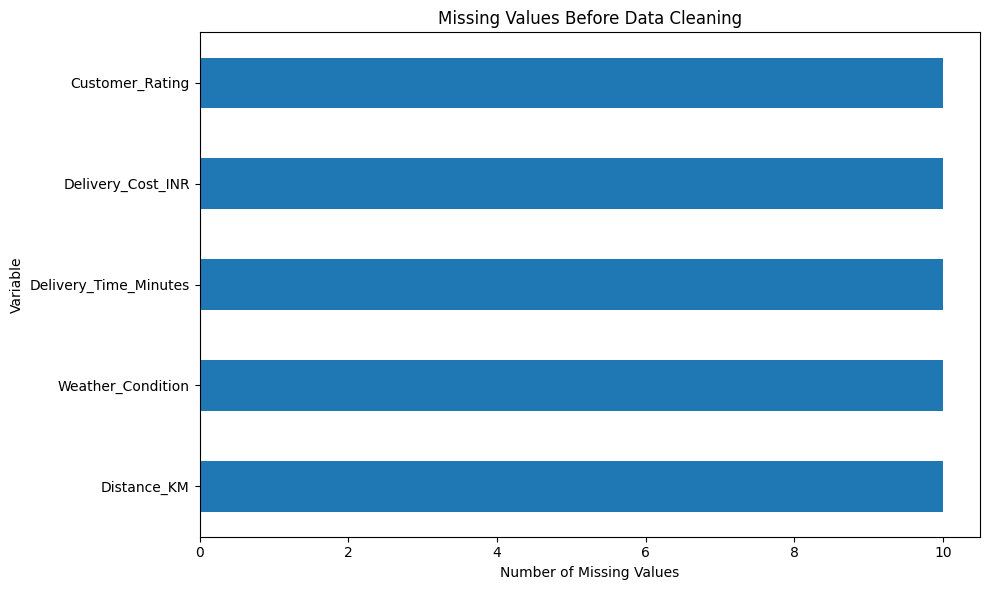

In [21]:
# ============================================
# MILESTONE 10 — DATA QUALITY VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import os

# Create figures folder
os.makedirs("figures", exist_ok=True)


# ============================================
# FIGURE 1 — MISSING VALUES BEFORE CLEANING
# ============================================

missing_counts = logistics_raw_issues_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(10, 6))

missing_counts.sort_values().plot(
    kind="barh"
)

plt.title("Missing Values Before Data Cleaning")
plt.xlabel("Number of Missing Values")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    "figures/missing_values_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

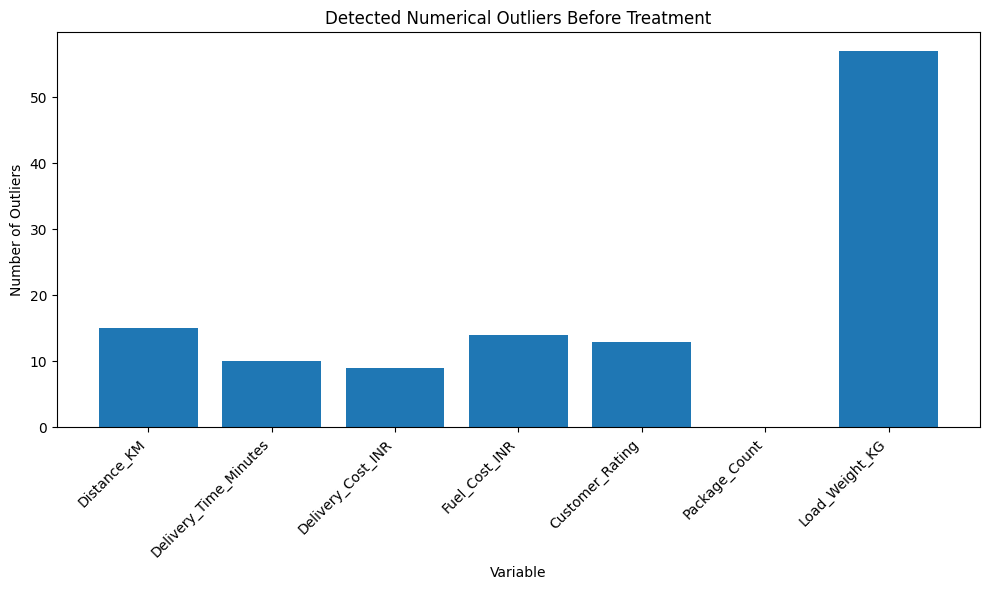

In [22]:
# ============================================
# FIGURE 2 — OUTLIERS BEFORE TREATMENT
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    outlier_summary_df["Column"],
    outlier_summary_df["Outlier_Count"]
)

plt.title("Detected Numerical Outliers Before Treatment")
plt.xlabel("Variable")
plt.ylabel("Number of Outliers")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "figures/outliers_before_treatment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

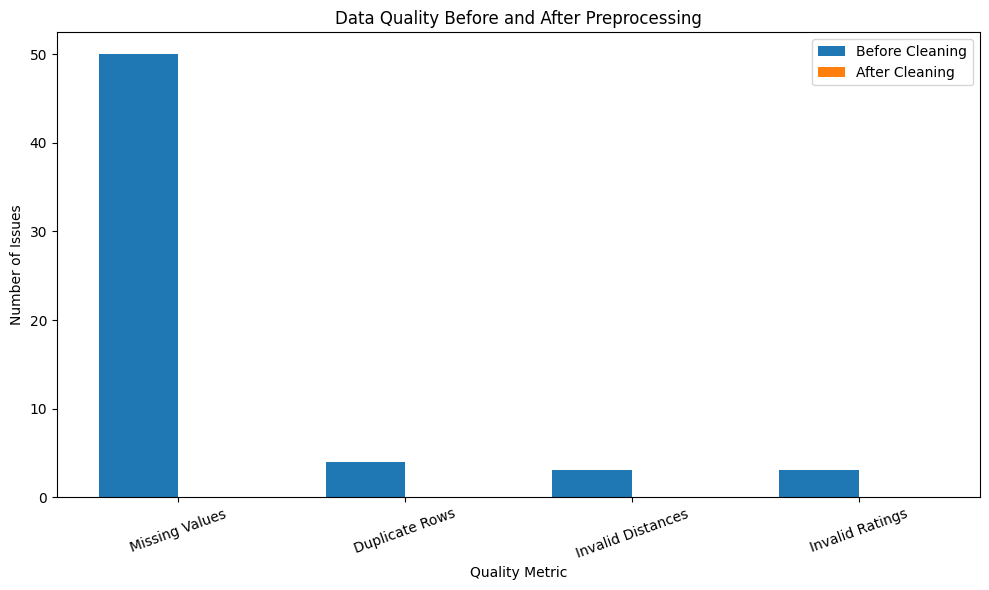

In [23]:
# ============================================
# FIGURE 3 — DATASET QUALITY BEFORE VS AFTER
# ============================================

quality_metrics = [
    "Missing Values",
    "Duplicate Rows",
    "Invalid Distances",
    "Invalid Ratings"
]

before_values = [
    logistics_raw_issues_df.isnull().sum().sum(),
    logistics_raw_issues_df.duplicated().sum(),
    (logistics_raw_issues_df["Distance_KM"] < 0).sum(),
    (
        (logistics_raw_issues_df["Customer_Rating"] < 1) |
        (logistics_raw_issues_df["Customer_Rating"] > 5)
    ).sum()
]

after_values = [
    preprocessed_logistics_df.isnull().sum().sum(),
    preprocessed_logistics_df.duplicated().sum(),
    (preprocessed_logistics_df["Distance_KM"] < 0).sum(),
    (
        (preprocessed_logistics_df["Customer_Rating"] < 1) |
        (preprocessed_logistics_df["Customer_Rating"] > 5)
    ).sum()
]

x = np.arange(len(quality_metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    before_values,
    width,
    label="Before Cleaning"
)

plt.bar(
    x + width / 2,
    after_values,
    width,
    label="After Cleaning"
)

plt.title("Data Quality Before and After Preprocessing")
plt.xlabel("Quality Metric")
plt.ylabel("Number of Issues")

plt.xticks(
    x,
    quality_metrics,
    rotation=20
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/data_quality_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
print("Figures created:")

print(os.listdir("figures"))

Figures created:
['data_quality_before_after.png', 'missing_values_before_cleaning.png', 'outliers_before_treatment.png']


In [26]:
# ============================================
# MILESTONE 11 — PREPROCESSING SUMMARY
# ============================================

preprocessing_summary = pd.DataFrame({
    "Stage": [
        "Original baseline dataset",
        "After simulated data-quality issues",
        "After duplicate removal",
        "After missing-value treatment",
        "After invalid-value treatment",
        "After outlier treatment",
        "Final preprocessed dataset"
    ],

    "Rows": [
        len(raw_logistics_df),
        len(logistics_raw_issues_df),
        len(cleaned_logistics_df),
        len(cleaned_logistics_df),
        len(cleaned_logistics_df),
        len(cleaned_logistics_df),
        len(preprocessed_logistics_df)
    ],

    "Columns": [
        len(raw_logistics_df.columns),
        len(logistics_raw_issues_df.columns),
        len(cleaned_logistics_df.columns),
        len(cleaned_logistics_df.columns),
        len(cleaned_logistics_df.columns),
        len(cleaned_logistics_df.columns),
        len(preprocessed_logistics_df.columns)
    ]
})

display(preprocessing_summary)

,Stage,Rows,Columns
0,Original baseline dataset,1000,16
1,After simulated data-quality issues,1005,16
2,After duplicate removal,1001,16
3,After missing-value treatment,1001,16
4,After invalid-value treatment,1001,16
5,After outlier treatment,1001,16
6,Final preprocessed dataset,1001,26


In [27]:
# Save preprocessing summary

preprocessing_summary.to_csv(
    "data/preprocessing_summary.csv",
    index=False
)

print("Preprocessing summary saved successfully.")

Preprocessing summary saved successfully.


In [28]:
print(os.listdir("data"))

['logistics_preprocessed.csv', 'logistics_cleaned.csv', 'logistics_raw_issues.csv', 'preprocessing_summary.csv']


In [29]:
# ============================================
# MILESTONE 12 — FINAL PREPROCESSING STATISTICS
# ============================================

final_statistics = pd.DataFrame({
    "Metric": [
        "Original records",
        "Records after issue simulation",
        "Duplicate records removed",
        "Final records",
        "Original columns",
        "Final columns",
        "Missing values remaining",
        "Duplicate rows remaining",
        "Negative distances remaining",
        "Invalid ratings remaining"
    ],

    "Value": [
        len(raw_logistics_df),
        len(logistics_raw_issues_df),
        (
            len(logistics_raw_issues_df)
            - len(cleaned_logistics_df)
        ),
        len(preprocessed_logistics_df),
        len(raw_logistics_df.columns),
        len(preprocessed_logistics_df.columns),
        preprocessed_logistics_df.isnull().sum().sum(),
        preprocessed_logistics_df.duplicated().sum(),
        (
            preprocessed_logistics_df["Distance_KM"] < 0
        ).sum(),
        (
            (preprocessed_logistics_df["Customer_Rating"] < 1) |
            (preprocessed_logistics_df["Customer_Rating"] > 5)
        ).sum()
    ]
})

display(final_statistics)

,Metric,Value
0,Original records,1000
1,Records after issue simulation,1005
2,Duplicate records removed,4
3,Final records,1001
4,Original columns,16
5,Final columns,26
6,Missing values remaining,0
7,Duplicate rows remaining,0
8,Negative distances remaining,0
9,Invalid ratings remaining,0


In [30]:
final_statistics.to_csv(
    "data/final_preprocessing_statistics.csv",
    index=False
)

print("Final preprocessing statistics saved.")

Final preprocessing statistics saved.


In [31]:
# ============================================
# PREPARE PROJECT FILES FOR DOWNLOAD
# ============================================

import shutil
import os

# Create project directory
project_folder = "Logistics-Data-Preprocessing"

os.makedirs(project_folder, exist_ok=True)

# Create subfolders
for folder in ["data", "figures", "notebooks", "reports"]:
    os.makedirs(
        os.path.join(project_folder, folder),
        exist_ok=True
    )

# Copy data files
for filename in [
    "logistics_raw_issues.csv",
    "logistics_cleaned.csv",
    "logistics_preprocessed.csv",
    "preprocessing_summary.csv",
    "final_preprocessing_statistics.csv"
]:
    shutil.copy(
        os.path.join("data", filename),
        os.path.join(project_folder, "data", filename)
    )

# Copy figures
for filename in os.listdir("figures"):
    if filename.endswith(".png"):
        shutil.copy(
            os.path.join("figures", filename),
            os.path.join(project_folder, "figures", filename)
        )

print("Project folder prepared successfully.")
print(os.listdir(project_folder))

Project folder prepared successfully.
['figures', 'notebooks', 'reports', 'data']


In [32]:
from google.colab import files
import os

csv_files = [
    "logistics_raw_issues.csv",
    "logistics_cleaned.csv",
    "logistics_preprocessed.csv",
    "preprocessing_summary.csv",
    "final_preprocessing_statistics.csv"
]

for filename in csv_files:
    files.download(os.path.join("data", filename))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>